# Análise dos resultados do enem-llm-benchmark

Neste notebook eu analiso como alguns modelos de linguagem gratuitos se saíram nas questões do ENEM 2025, partindo do CSV que o benchmark gera. A pergunta que me guia é direta, quão bem esses modelos respondem à prova, e em que áreas eles erram mais, comparando modelo a modelo. Todo o resultado vem de `results/resultados.csv`, que tem uma linha por modelo e questão, com a letra respondida, o gabarito e se o modelo acertou.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

ordem_areas = ["linguagens", "humanas", "natureza", "matematica"]
rotulos = {
    "linguagens": "Linguagens",
    "humanas": "Ciências Humanas",
    "natureza": "Ciências da Natureza",
    "matematica": "Matemática",
}

df = pd.read_csv("../results/resultados.csv")
print(f"{len(df)} respostas de {df['modelo'].nunique()} modelos")
print(f"{df['questao_id'].nunique()} questões distintas avaliadas")
df.head()

348 respostas de 3 modelos
116 questões distintas avaliadas


,questao_id,modelo,ano,area,tem_imagem,alternativa,gabarito,acertou
0,enem-2025-01,groq-llama-8b,2025,linguagens,0,D,D,1
1,enem-2025-02,groq-llama-8b,2025,linguagens,0,D,D,1
2,enem-2025-03,groq-llama-8b,2025,linguagens,0,D,D,1
3,enem-2025-04,groq-llama-8b,2025,linguagens,0,E,E,1
4,enem-2025-06,groq-llama-8b,2025,linguagens,0,A,E,0


## O conjunto avaliado

Antes de olhar a acurácia, vale dimensionar o que estou medindo, porque amostras pequenas pedem cautela na hora de concluir. A contagem abaixo mostra quantas questões distintas há em cada área neste recorte, que é só de questões de texto, já que os modelos puramente textuais não enxergam imagem.

In [2]:
questoes = df.drop_duplicates("questao_id")
contagem = questoes["area"].value_counts().reindex(ordem_areas)
contagem.index = [rotulos[a] for a in contagem.index]
contagem.to_frame("questões de texto")

,questões de texto
Linguagens,33
Ciências Humanas,40
Ciências da Natureza,21
Matemática,22


## Acurácia geral e por modelo

A acurácia é a fração de questões que o modelo acertou, comparando a letra que ele respondeu com o gabarito. Reporto junto o número de questões, para deixar explícito sobre quanto cada taxa foi calculada.

In [3]:
print(f"Acurácia geral: {df['acertou'].mean():.1%} ({df['acertou'].sum()} de {len(df)})")
por_modelo = df.groupby("modelo")["acertou"].agg(["mean", "count"])
por_modelo["mean"] = (por_modelo["mean"] * 100).round(1)
por_modelo.columns = ["acurácia (%)", "questões"]
por_modelo.sort_values("acurácia (%)", ascending=False)

Acurácia geral: 72.1% (251 de 348)


,acurácia (%),questões
modelo,,
groq-llama-70b,82.8,116
groq-gpt-oss-20b,75.9,116
groq-llama-8b,57.8,116


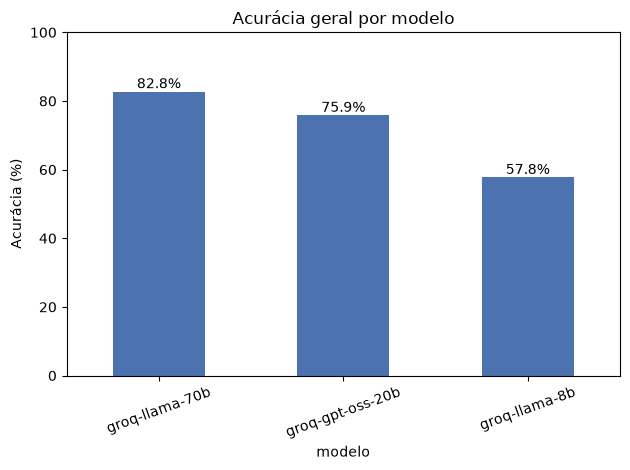

In [4]:
acc = df.groupby("modelo")["acertou"].mean().mul(100).sort_values(ascending=False)
ax = acc.plot.bar(ylim=(0, 100), ylabel="Acurácia (%)", rot=20, color="#4C72B0")
ax.set_title("Acurácia geral por modelo")
ax.bar_label(ax.containers[0], fmt="%.1f%%")
plt.tight_layout()
plt.show()

## Acurácia por área

Aqui dá para ver onde a prova aperta. As ciências humanas e da natureza costumam sair na frente, e a matemática é a área mais difícil para todos os modelos, o que combina com a percepção de quem presta o ENEM.

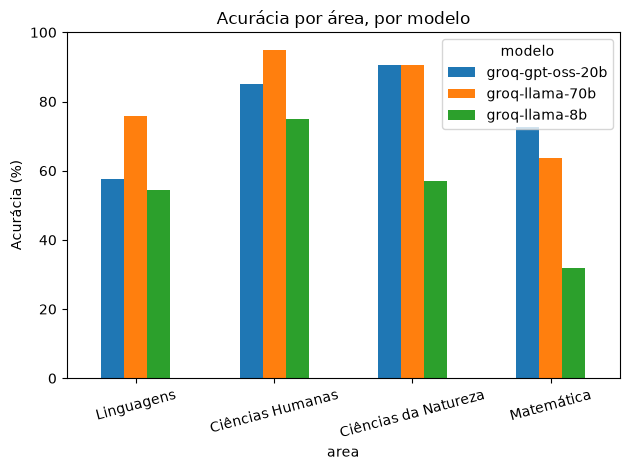

area,Linguagens,Ciências Humanas,Ciências da Natureza,Matemática
modelo,,,,
groq-gpt-oss-20b,57.6,85.0,90.5,72.7
groq-llama-70b,75.8,95.0,90.5,63.6
groq-llama-8b,54.5,75.0,57.1,31.8


In [5]:
tabela = df.pivot_table(index="modelo", columns="area", values="acertou", aggfunc="mean").mul(100)
tabela = tabela.reindex(columns=ordem_areas)
tabela_rotulada = tabela.rename(columns=rotulos)
ax = tabela_rotulada.T.plot.bar(ylim=(0, 100), ylabel="Acurácia (%)", rot=15)
ax.set_title("Acurácia por área, por modelo")
ax.legend(title="modelo")
plt.tight_layout()
plt.show()
tabela_rotulada.round(1)

## Modelo por área, o mapa de calor

O mapa de calor resume a comparação numa figura só, e é onde aparece o achado que mais me chamou atenção. O GPT-OSS de 20 bilhões de parâmetros, que é o menor dos três, supera o Llama de 70 bilhões justamente em matemática, mesmo perdendo para ele nas outras áreas. Modelo maior não vence em tudo, e a área mais difícil da prova acabou premiando o modelo aberto da OpenAI, treinado com foco em raciocínio.

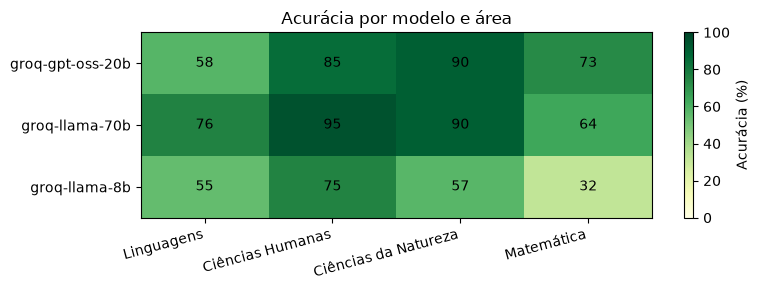

In [6]:
fig, ax = plt.subplots(figsize=(8, 3))
imagem = ax.imshow(tabela.values, cmap="YlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(ordem_areas)))
ax.set_xticklabels([rotulos[a] for a in ordem_areas], rotation=15, ha="right")
ax.set_yticks(range(len(tabela.index)))
ax.set_yticklabels(tabela.index)
for i in range(len(tabela.index)):
    for j in range(len(ordem_areas)):
        ax.text(j, i, f"{tabela.values[i][j]:.0f}", ha="center", va="center")
fig.colorbar(imagem, ax=ax, label="Acurácia (%)")
ax.set_title("Acurácia por modelo e área")
plt.tight_layout()
plt.show()

## Onde os modelos erram juntos, e onde divergem

Há questões que os três modelos erraram, e essas são candidatas a questão genuinamente difícil, ou a algum ruído na forma como extraí o texto da prova do PDF. Outras dividiram os modelos, com parte acertando e parte errando, e essas são as mais úteis para diferenciar um modelo do outro.

In [7]:
n_modelos = df["modelo"].nunique()
soma = df.groupby("questao_id")["acertou"].sum()
todos_erraram = soma[soma == 0]
todos_acertaram = soma[soma == n_modelos]
divergiram = soma[(soma > 0) & (soma < n_modelos)]
print(f"Questões que todos erraram: {len(todos_erraram)}")
print(f"Questões que todos acertaram: {len(todos_acertaram)}")
print(f"Questões em que os modelos divergiram: {len(divergiram)}")
dificeis = questoes[questoes["questao_id"].isin(todos_erraram.index)]
dificeis["area"].map(rotulos).value_counts().to_frame("questões que todos erraram")

Questões que todos erraram: 13
Questões que todos acertaram: 60
Questões em que os modelos divergiram: 43


,questões que todos erraram
area,
Linguagens,6
Matemática,6
Ciências Humanas,1


## Conclusão e limitações

Resumindo, o Llama de 70B lidera no geral, o GPT-OSS de 20B se destaca em matemática, e o Llama de 8B fica para trás em todas as áreas, como se esperava de um modelo bem menor. Há limites importantes a registrar com honestidade. As amostras por área são pequenas, então cada taxa carrega uma margem de erro considerável, e diferenças de poucos pontos não devem ser superinterpretadas. Este recorte usa apenas questões de texto, já que os modelos puramente textuais não leem imagem, então as questões com figura ficaram fora da comparação. E todo o resultado depende de como extraí a prova do PDF e de como o modelo redige a resposta, por isso vale inspecionar caso a caso os erros comentados em `docs/erros_comentados.md`.